<a href="https://colab.research.google.com/github/AlexeyTri/Home_work_NN/blob/main/HomeWork_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/AlexeyTri/Home_work_NN/refs/heads/main/data/svm-data.csv")

In [2]:
from sklearn.svm import SVC
import seaborn as sns

In [5]:
df

,0.0,0.7,0.29
0,1.0,0.23,0.55
1,0.0,0.72,0.42
2,0.0,0.98,0.68
3,0.0,0.48,0.39
4,1.0,0.34,0.73
5,0.0,0.44,0.06
6,1.0,0.40,0.74
7,0.0,0.18,0.18
8,1.0,0.53,0.53


In [30]:
df.iloc[2,:].values[2].item()

0.68

In [7]:
svc = SVC(C=100000, kernel='linear', random_state=241)
X = df.iloc[:, 1:]
y = df['0.0']

In [8]:
svc.fit(X, y)

SVC(C=100000, kernel='linear', random_state=241)

In [55]:
!echo {svc.support_.tolist()} >> 6.txt

Text(0.5, 1.0, 'SVC')

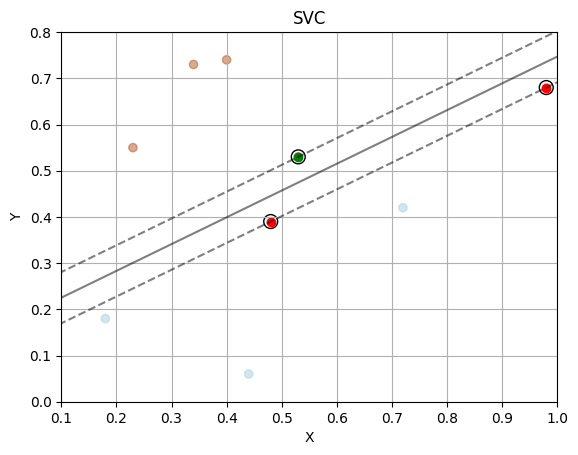

In [74]:
plt.scatter(df.iloc[:, 1], df.iloc[:, 2], c=df.iloc[:, 0], alpha=0.5, cmap=plt.cm.Paired)
plt.scatter(df.iloc[2, 1], df.iloc[2, 2], c="red", alpha=1)
plt.scatter(df.iloc[3, 1], df.iloc[3, 2], c="red", alpha=1)
plt.scatter(df.iloc[8, 1], df.iloc[8, 2], c="green", alpha=1)

ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    svc,
    X,
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)
ax.scatter(
    svc.support_vectors_[:, 0],
    svc.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors="none",
    edgecolors="k",
)
plt.ylim([0.0, 0.8])
plt.xlim([0.1, 1.0])
plt.grid(True)
plt.ylabel("Y")
plt.xlabel("X")
plt.title("SVC")